## **7: Model Evaluation in sklearn**

### **7.1 Classification Metrics**

**7.1.1 Accuracy**
```bash
Accu_score = accuracy_score(y_true, y_pred, normalize=True)
```

**Parameters:**
* y_true → actual labels
* y_pred → predicted labels
* normalize → True (ratio), False (count)

**7.1.2 Confusion Matrix**
```bash
matrix = confusion_matrix(y_true, y_pred, labels=None)
```
**Output:**

[[TN FP] <br>
[FN TP]]

**7.1.3 Classification Report**
```bash
classification_report(y_true, y_pred)
```
**Gives:**
* Precision
* Recall
* F1-score
* Support

**7.1.4 Precision**
```bash
precision_score(y_true, y_pred, average='binary')
```

**7.1.5 Recall**
```bash
recall_score(y_true, y_pred, average='binary')
```

**7.1.6 F1 Score**
```bash
f1_score(y_true, y_pred, average='binary')
```

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [2]:
# Predictions
y_pred = model.predict(X_test)

# 🔹 Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# 🔹 Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 🔹 Classification Report (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 🔹 Individual Metrics (for binary mostly, but works with average)
print("\nPrecision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Precision: 1.0
Recall: 1.0
F1 Score: 1.0


### **7.2 ROC Curve & AUC**

**ROC Curve:**
```bash
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
```
**Parameters**
* y_true -> Actual labels
* y_prob -> Predicted probabilities of positive class (class = 1)

**Returns 3 values:**
* fpr (False Positive Rate)
    * how many negative points are wrongly predicted as positive
* tpr (True Positive Rate / Recall)
    * how many positive points are correctly predicted
* thresholds
    * different cutoff values used to decide class (like 0.5, 0.3, etc.)

**AUC Score:**
```bash
roc_auc_score(y_true, y_prob)
```

**Returns**
→ overall performance score(0-1) of the model

AUC Score: 0.9977071732721913


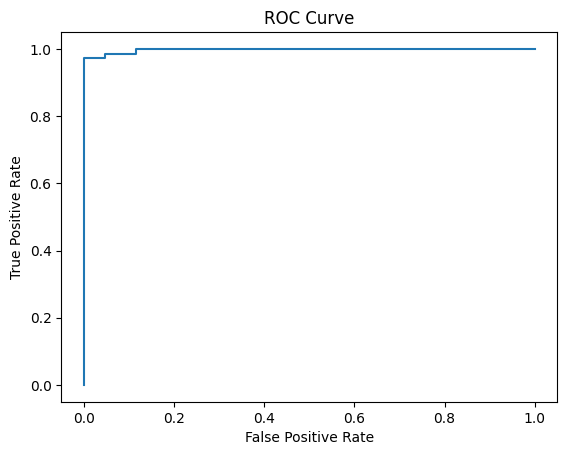

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Load dataset (binary classification)
X, y = load_breast_cancer(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Get probability (important for ROC)
y_prob = model.predict_proba(X_test)[:, 1]

# 🔹 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 🔹 AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# 🔹 Plot ROC Curve
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### **7.3 Regression Metrics**

**7.3.1 Mean Squared Error (MSE)**
```bash
mean_squared_error(y_true, y_pred)
```

**7.3.2 Mean Absolute Error (MAE)**
```bash
mean_absolute_error(y_true, y_pred)
```

**7.3.3 R² Score**
```bash
r2_score(y_true, y_pred)
```

In [4]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Load dataset
X, y = load_diabetes(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
# Predictions
y_pred = model.predict(X_test)

# 🔹 Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   # RMSE manually
r2 = r2_score(y_test, y_pred)

# Print results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 42.79409467959994
MSE: 2900.1936284934804
RMSE: 53.85344583676592
R2 Score: 0.4526027629719197


### **7.4 Cross Validation**

**Syntax:**

```bash
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring=None
)
```

**Parameters:**
* model
* cv → folds (e.g., 5)
* scoring → metric

**Example (Classification)**

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
X, y = load_iris(return_X_y=True)

# Create model
model = KNeighborsClassifier()

# Apply cross-validation (5-fold)
scores = cross_val_score(model, X, y, cv=5)

# Print results
print("Scores:", scores)
print("Average Score:", scores.mean())

Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Average Score: 0.9733333333333334


**Example (Regression)**

In [7]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Load dataset
X, y = load_diabetes(return_X_y=True)

# Model
model = LinearRegression()

# Cross-validation
scores = cross_val_score(model, X, y, cv=5)

print("Scores:", scores)
print("Average Score:", scores.mean())

Scores: [0.42955615 0.52259939 0.48268054 0.42649776 0.55024834]
Average Score: 0.4823164359086422
